# CryptoCast: Multi-Horizon Bitcoin Price Forecasting Using Deep Learning

## Financial Analytics | Deep Learning | Time Series Forecasting

### Objective
Develop deep learning models (CNN, RNN, LSTM, and Transformer) to forecast Bitcoin prices for 1-day, 3-day, and 7-day horizons using historical Bitcoin market data.

# 1. Import Required Libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, LSTM, SimpleRNN, Conv1D, MaxPooling1D, Flatten, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

# 2. Load the Dataset

In [71]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Bitcoin_Data.csv")
df.head(5)

Saving Bitcoin_Data.csv to Bitcoin_Data (1).csv


,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.90","64,036.50","67,587.80","63,812.90",65.59K,4.96%
1,23-03-2024,"64,037.80","63,785.60","65,972.40","63,074.90",35.11K,0.40%
2,22-03-2024,"63,785.50","65,501.50","66,633.30","62,328.30",72.43K,-2.62%
3,21-03-2024,"65,503.80","67,860.00","68,161.70","64,616.10",75.26K,-3.46%
4,20-03-2024,"67,854.00","62,046.80","68,029.50","60,850.90",133.53K,9.35%


## 3. Exploratory Data Analysis (EDA)

In [72]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      4999 non-null   object
 1   Price     4999 non-null   object
 2   Open      4999 non-null   object
 3   High      4999 non-null   object
 4   Low       4999 non-null   object
 5   Vol.      4993 non-null   object
 6   Change %  4999 non-null   object
dtypes: object(7)
memory usage: 273.5+ KB


,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,6
Change %,0


## 4. Data Cleaning and Preprocessing


In [73]:
df["Date"] = pd.to_datetime(df["Date"],format = "%d-%m-%Y")

In [74]:
df = df.sort_values("Date")
df.reset_index(drop=True,inplace = True)

In [75]:
df.head(5)

,Date,Price,Open,High,Low,Vol.,Change %
0,2010-07-18,0.1,0,0.1,0.1,0.08K,0.00%
1,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
2,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
3,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%


In [76]:
df["Price"] = df["Price"].str.replace(",","",regex = False)
df["Price"] = df["Price"].astype(float)

## 5. Feature Selection

In [77]:
price_data = df[["Price"]]
price_data.head(5)

,Price
0,0.1
1,0.1
2,0.1
3,0.1
4,0.1


## 6. Feature Scaling

In [78]:
scaler = MinMaxScaler()
scaled_price = scaler.fit_transform(price_data)

In [79]:
scaled_price[:5]
scaled_price.shape

(4999, 1)


## 7. Sequence Generation

In [80]:
#Sequence Generation
def createmulti_horizon_sequence(data,sequence_length):
  x = []
  y = []
  for i in range(sequence_length, len(data)-6):
    x.append(data[i-sequence_length:i])
    y.append([data[i][0],data[i+2][0],data[i+6][0]])
  return np.array(x), np.array(y)

In [81]:
sequence_length = 60
x,y = createmulti_horizon_sequence(scaled_price,sequence_length)
print("X Shape:", x.shape)
print("y Shape:", y.shape)

X Shape: (4933, 60, 1)
y Shape: (4933, 3)


## 8. Train-Test Split

In [82]:
train_size = int(len(x)*0.8)
print(train_size)

3946


In [83]:
x_train= x[:train_size]
x_test= x[train_size:]

y_train = y[:train_size]
y_test= y[train_size:]
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (3946, 60, 1)
x_test : (987, 60, 1)
y_train: (3946, 3)
y_test : (987, 3)


## 9. LSTM Model

In [84]:
#Creating a LSTM model
model = Sequential()
model.add(LSTM(64,input_shape= (x_train.shape[1],x_train.shape[2])))
model.add(Dense(3))
model.compile(optimizer='adam',loss="mse")
model.summary()




Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,091 (66.76 KB)

 Trainable params: 17,091 (66.76 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
early_stop = EarlyStopping(monitor ='val_loss', patience = 5, restore_best_weights = True)
history = model.fit(x_train,y_train,epochs=20,batch_size=32,validation_data=(x_test, y_test,),callbacks=[early_stop])


Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0028 - val_loss: 0.0021
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.5594e-04 - val_loss: 0.0043
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.2846e-04 - val_loss: 0.0017
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.8139e-04 - val_loss: 0.0017
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.5191e-04 - val_loss: 0.0020
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.4200e-04 - val_loss: 0.0015
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3439e-04 - val_loss: 0.0015
Epoch 8/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.9066e-04 - val_loss: 0.0014
Epoch 9/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1116e-04 - val_loss: 0.0018
Epoch 10/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8296e-04 - val_loss: 0.0013
Epoch 11/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8014e-04 - val_loss: 0.0020
Epoch 12/20

In [86]:
y_pred = model.predict(x_test)
print(y_pred.shape)
print(y_pred[:5])
y_pred_actual = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)
print(y_pred_actual[:5])
print(y_test_actual[:5])

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
(987, 3)
[[0.483801   0.47416016 0.47901818]
 [0.48159605 0.4717622  0.47675884]
 [0.47897798 0.4691458  0.47414318]
 [0.47313014 0.46342495 0.46808645]
 [0.47162563 0.46182576 0.46709737]]
[[35349.6   34645.18  35000.137]
 [35188.492 34469.973 34835.06 ]
 [34997.2   34278.8   34643.94 ]
 [34569.92  33860.8   34201.4  ]
 [34459.992 33743.953 34129.13 ]]
[[34225.6 32866.3 33113. ]
 [33867.8 33797.4 32728.1]
 [32866.3 33510.6 32820.7]
 [33797.4 34227.7 31840.5]
 [33510.6 33113.  31394. ]]


In [87]:
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

print("y_test_actual shape:", y_test_actual.shape)
print("y_pred_actual shape:", y_pred_actual.shape)

y_test shape: (987, 3)
y_pred shape: (987, 3)
y_test_actual shape: (987, 3)
y_pred_actual shape: (987, 3)


In [88]:
# LSTM Evaluation

horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):

    lstm_mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
    lstm_rmse = np.sqrt(mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i]))
    lstm_r2 = r2_score(y_test_actual[:, i], y_pred_actual[:, i])

    print(f"\n{horizons[i]} Forecast")
    print("----------------------")
    print("MAE :", lstm_mae)
    print("RMSE:", lstm_rmse)
    print("R² Score:", lstm_r2)


1-Day Forecast
----------------------
MAE : 1266.0659087670977
RMSE: 1667.33378541677
R² Score: 0.9829298204815048

3-Day Forecast
----------------------
MAE : 1519.0613914482014
RMSE: 2199.781120302424
R² Score: 0.9706369942110987

7-Day Forecast
----------------------
MAE : 2314.4560398461244
RMSE: 3256.83370583977
R² Score: 0.9371177970198589


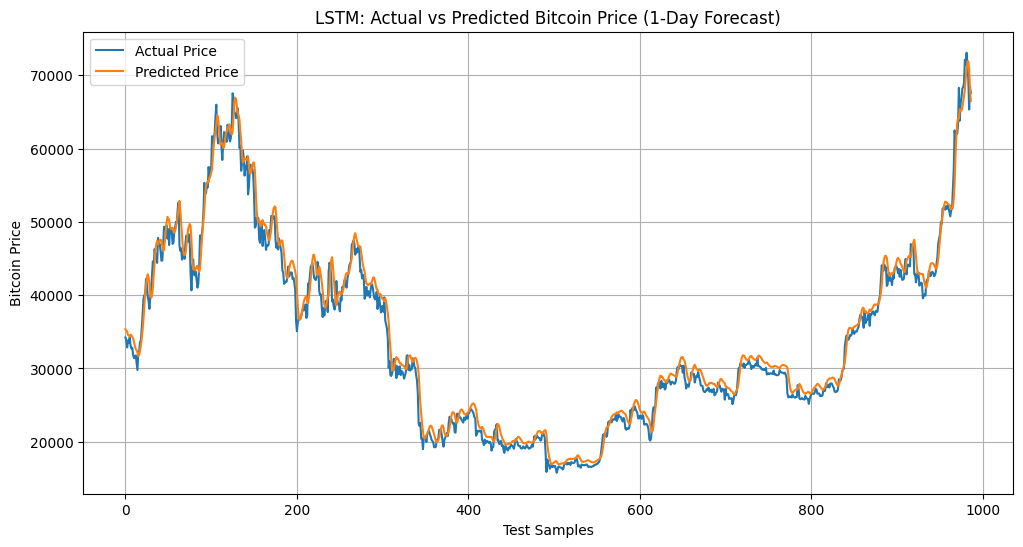

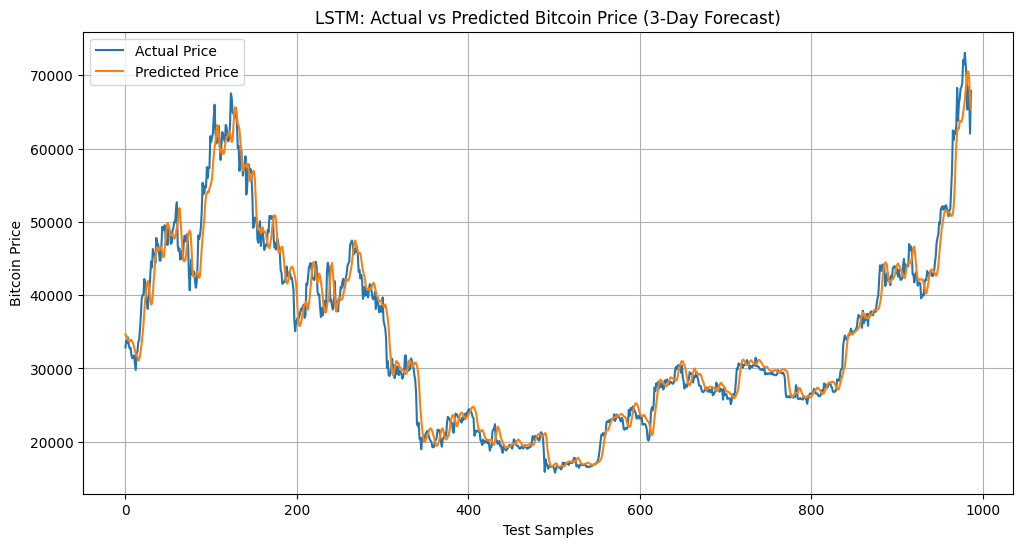

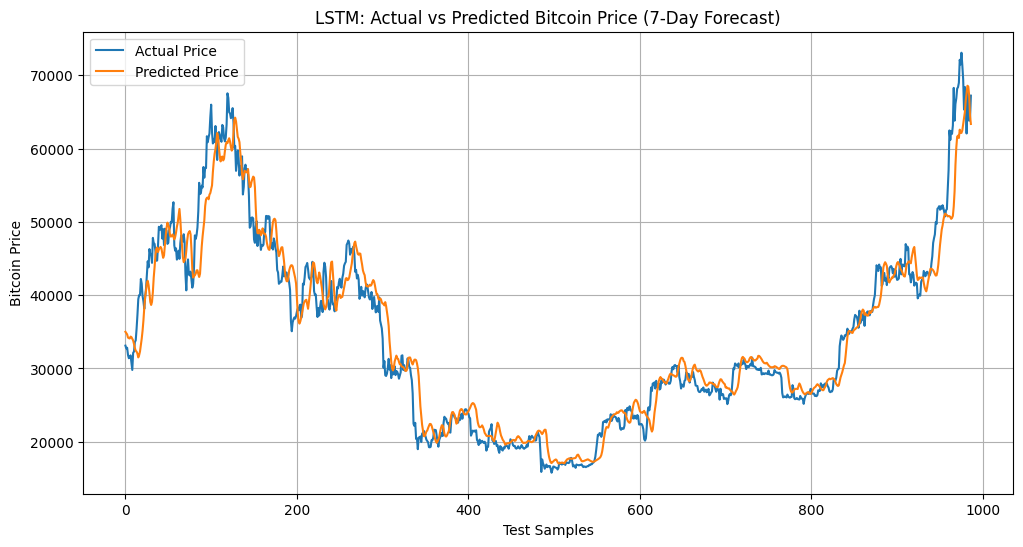

In [89]:
#LSTM Visualization
horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):

    plt.figure(figsize=(12,6))

    plt.plot(y_test_actual[:, i], label="Actual Price")
    plt.plot(y_pred_actual[:, i], label="Predicted Price")

    plt.title(f"LSTM: Actual vs Predicted Bitcoin Price ({horizons[i]} Forecast)")
    plt.xlabel("Test Samples")
    plt.ylabel("Bitcoin Price")
    plt.legend()
    plt.grid(True)

    plt.show()

## 10. RNN Model

In [90]:
#Creating a RNN model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(64,input_shape=(x_train.shape[1],x_train.shape[2])))
rnn_model.add(Dense(3))
rnn_model.compile(optimizer='adam',loss='mse')
rnn_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,419 (17.26 KB)

 Trainable params: 4,419 (17.26 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
rnn_history = rnn_model.fit(x_train,y_train,epochs=20, batch_size=32,validation_data = (x_test,y_test),callbacks=[early_stop])
rnn_pred = rnn_model.predict(x_test)
rnn_pred_actual = scaler.inverse_transform(rnn_pred)
y_test_actual = scaler.inverse_transform(y_test)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0024 - val_loss: 0.0026
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.6871e-04 - val_loss: 0.0027
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.6225e-04 - val_loss: 0.0019
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0607e-04 - val_loss: 0.0018
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.6961e-04 - val_loss: 0.0019
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [92]:
# ENN Evaluation
horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):
    rnn_mae = mean_absolute_error(y_test_actual[:, i], rnn_pred_actual[:, i])
    rnn_rmse = np.sqrt(mean_squared_error(y_test_actual[:, i], rnn_pred_actual[:, i]))
    rnn_r2 = r2_score(y_test_actual[:, i], rnn_pred_actual[:, i])

    print(f"\n{horizons[i]} Forecast")
    print("----------------------")
    print("MAE :", rnn_mae)
    print("RMSE:", rnn_rmse)
    print("R² Score:", rnn_r2)


1-Day Forecast
----------------------
MAE : 1453.069614559587
RMSE: 1894.521771055572
R² Score: 0.9779609846046711

3-Day Forecast
----------------------
MAE : 3946.2306618857647
RMSE: 4916.24910709381
R² Score: 0.8533407934517256

7-Day Forecast
----------------------
MAE : 2762.5562771102454
RMSE: 3803.8277134305977
R² Score: 0.9142215377163134


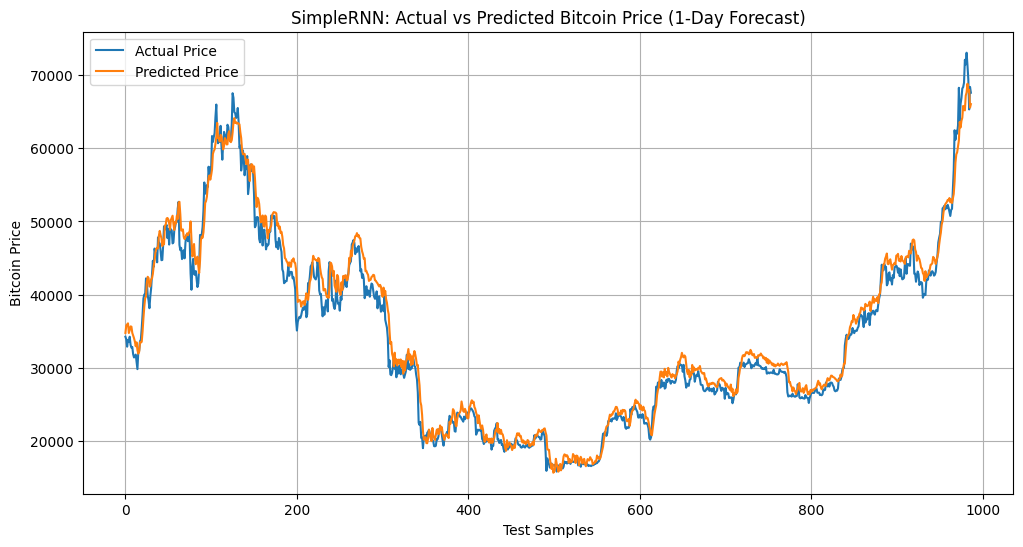

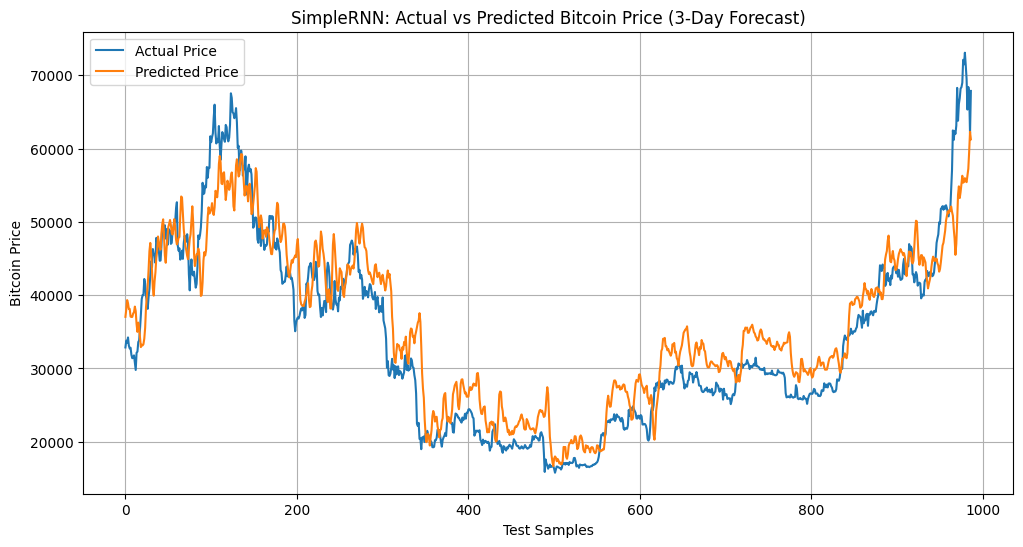

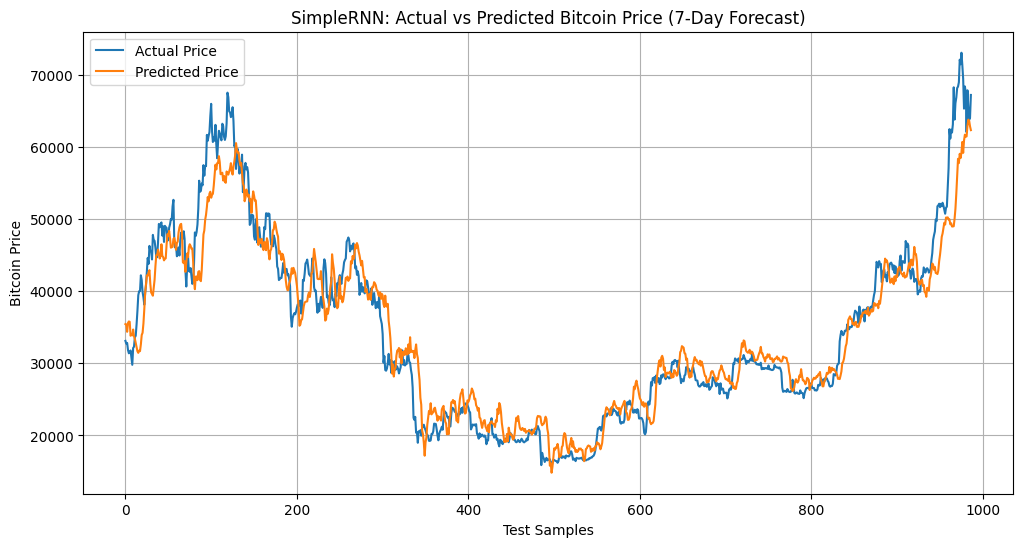

In [93]:
#RNN Visualization

horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):

    plt.figure(figsize=(12,6))

    plt.plot(y_test_actual[:, i], label="Actual Price")
    plt.plot(rnn_pred_actual[:, i], label="Predicted Price")

    plt.title(f"SimpleRNN: Actual vs Predicted Bitcoin Price ({horizons[i]} Forecast)")
    plt.xlabel("Test Samples")
    plt.ylabel("Bitcoin Price")
    plt.legend()
    plt.grid(True)

    plt.show()

## 11. CNN Model

In [94]:
#Creating a CNN model
cnn_model = Sequential()
cnn_model.add(Conv1D(filters = 64,kernel_size=3,activation="relu",input_shape=(x_train.shape[1],x_train.shape[2])))
cnn_model.add(MaxPooling1D(pool_size= 2))
cnn_model.add(Flatten())
cnn_model.add(Dense(50,activation="relu"))
cnn_model.add(Dense(3))
cnn_model.compile(optimizer="adam",loss="mse")
cnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │        92,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,259 (364.29 KB)

 Trainable params: 93,259 (364.29 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
cnn_history=cnn_model.fit(x_train,y_train,epochs=20,batch_size=32,validation_data=(x_test,y_test),callbacks=[early_stop])

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0017 - val_loss: 0.0042
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9847e-04 - val_loss: 0.0060
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.5171e-04 - val_loss: 0.0025
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4001e-04 - val_loss: 0.0042
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3326e-04 - val_loss: 0.0018


In [96]:
cnn_pred=cnn_model.predict(x_test)
cnn_pred_actual = scaler.inverse_transform(cnn_pred)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [97]:
# CNN Evaluation
horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):
    cnn_mae = mean_absolute_error(y_test_actual[:, i], cnn_pred_actual[:, i])
    cnn_rmse = np.sqrt(mean_squared_error(y_test_actual[:, i], cnn_pred_actual[:, i]))
    cnn_r2 = r2_score(y_test_actual[:, i], cnn_pred_actual[:, i])

    print(f"\n{horizons[i]} Forecast")
    print("----------------------")
    print("MAE :", cnn_mae)
    print("RMSE:", cnn_rmse)
    print("R² Score:", cnn_r2)


1-Day Forecast
----------------------
MAE : 4128.401619886651
RMSE: 5020.177806960523
R² Score: 0.8452498115893414

3-Day Forecast
----------------------
MAE : 2951.2564567898303
RMSE: 4152.717481963304
R² Score: 0.895357925149387

7-Day Forecast
----------------------
MAE : 3855.0435449911342
RMSE: 5006.732396376438
R² Score: 0.8513909222123763


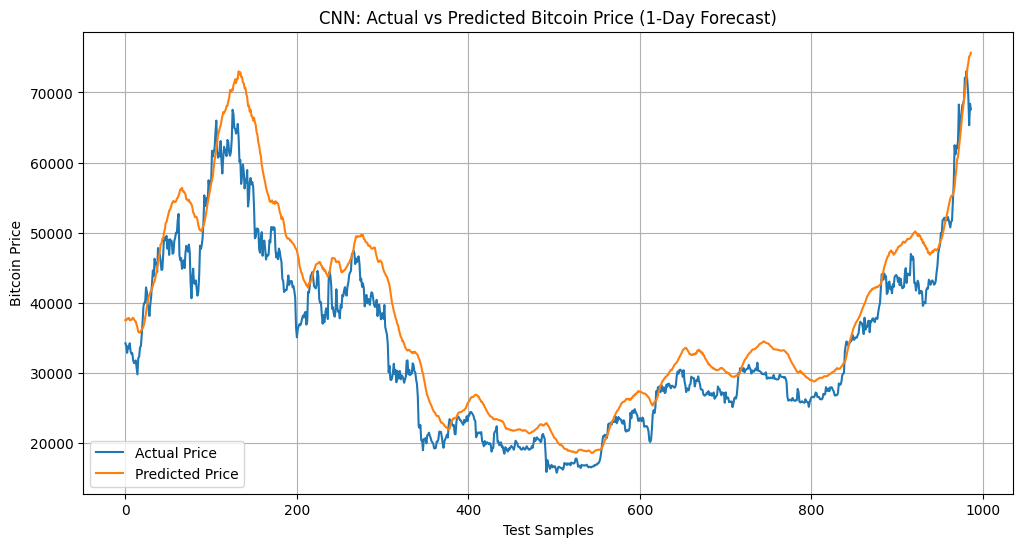

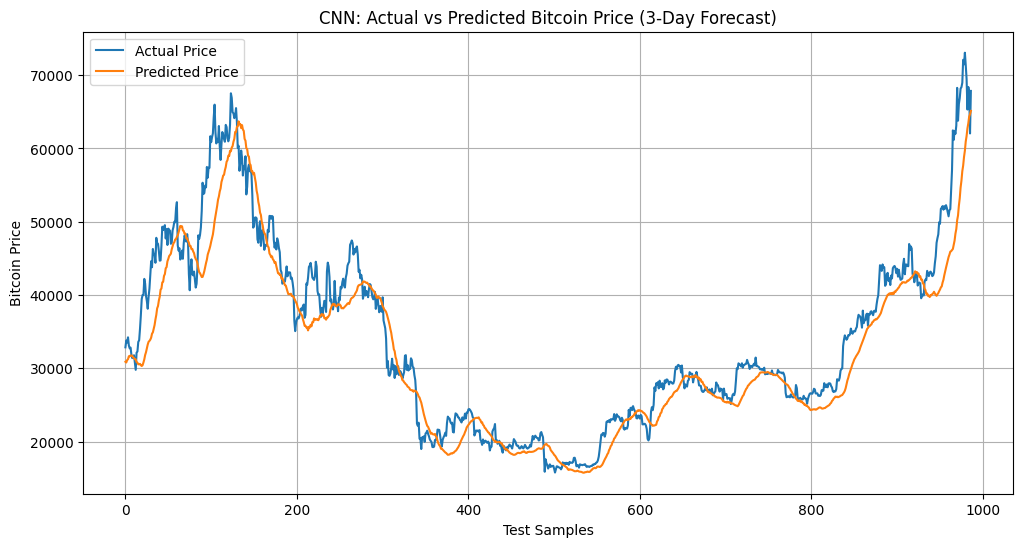

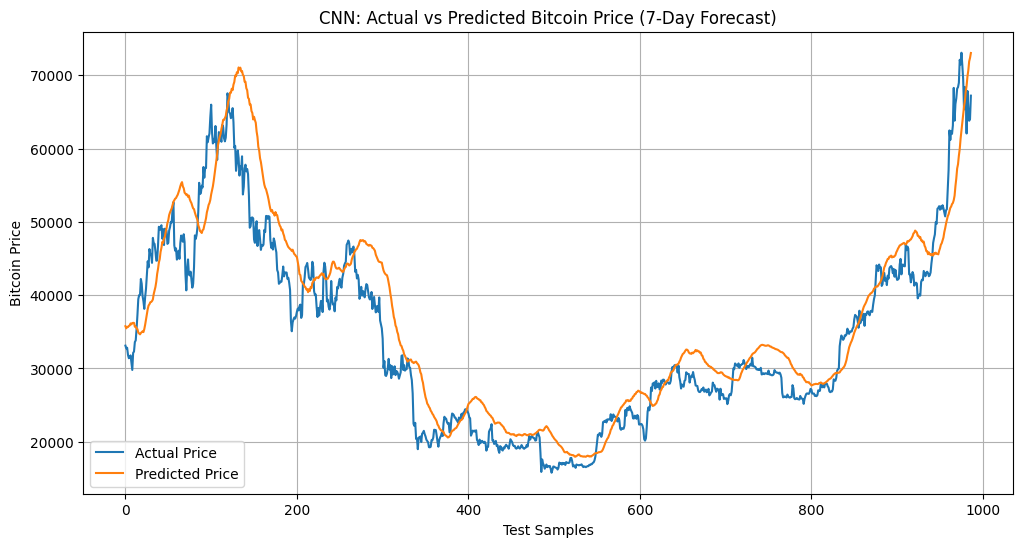

In [98]:
#CNN Visualization

horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):

    plt.figure(figsize=(12,6))

    plt.plot(y_test_actual[:, i], label="Actual Price")
    plt.plot(cnn_pred_actual[:, i], label="Predicted Price")

    plt.title(f"CNN: Actual vs Predicted Bitcoin Price ({horizons[i]} Forecast)")
    plt.xlabel("Test Samples")
    plt.ylabel("Bitcoin Price")
    plt.legend()
    plt.grid(True)

    plt.show()

## 12. Transformer Model

In [99]:
#Creating a Transformer model
from tensorflow.keras.layers import (Input,Dense,LayerNormalization,MultiHeadAttention,GlobalAveragePooling1D, Dropout)
from tensorflow.keras.models import Model
inputs =  Input(shape=(x_train.shape[1],x_train.shape[2]))
attention = MultiHeadAttention(num_heads=4, key_dim=16)(inputs,inputs)
x = attention + inputs
x = LayerNormalization()(x)
x = Dense(64,activation = 'relu')(x)
x = Dropout(0.2)(x)
x = GlobalAveragePooling1D()(x)
outputs = Dense(3)(x)
transformer_model = Model(inputs=inputs,outputs=outputs)
transformer_model.compile(optimizer='adam',loss = 'mse')
transformer_model.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 1)     │        449 │ input_layer_8[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 1)     │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 60, 64)    │        128 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 60, 64)    │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_3[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 3)         │        195 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 774 (3.02 KB)

 Trainable params: 774 (3.02 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
transformer_history = transformer_model.fit(x_train,y_train,epochs=20,batch_size=32,validation_data=(x_test,y_test),callbacks=[early_stop])


Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0209 - val_loss: 0.1934
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0197 - val_loss: 0.1925
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0197 - val_loss: 0.1884
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0197 - val_loss: 0.1905
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0197 - val_loss: 0.1905


In [101]:
transformer_pred = transformer_model.predict(x_test)



31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [102]:
transformer_pred_actual = scaler.inverse_transform(transformer_pred)

In [103]:
#Transformer Evalaution
horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):

    transformer_mae = mean_absolute_error(
        y_test_actual[:, i],
        transformer_pred_actual[:, i]
    )

    transformer_rmse = np.sqrt(
        mean_squared_error(
            y_test_actual[:, i],
            transformer_pred_actual[:, i]
        )
    )

    transformer_r2 = r2_score(
        y_test_actual[:, i],
        transformer_pred_actual[:, i]
    )

    print(f"\n{horizons[i]} Forecast")
    print("----------------------")
    print("MAE :", transformer_mae)
    print("RMSE:", transformer_rmse)
    print("R² Score:", transformer_r2)


1-Day Forecast
----------------------
MAE : 29361.648107130983
RMSE: 32015.05267606287
R² Score: -5.293633212272544

3-Day Forecast
----------------------
MAE : 29418.636109758896
RMSE: 32097.610729107495
R² Score: -5.251539527062344

7-Day Forecast
----------------------
MAE : 29546.769937903682
RMSE: 32275.24665736585
R² Score: -5.175551104861358


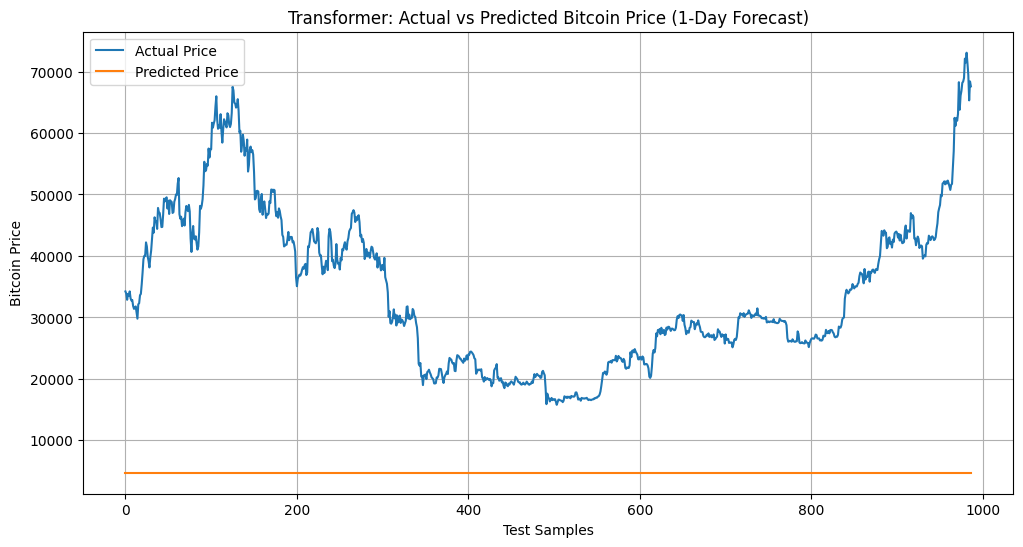

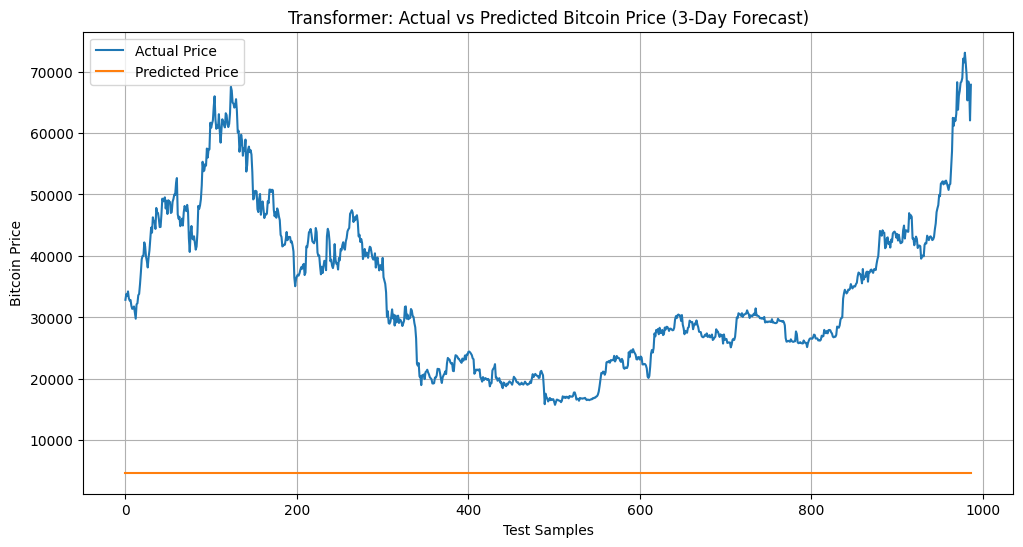

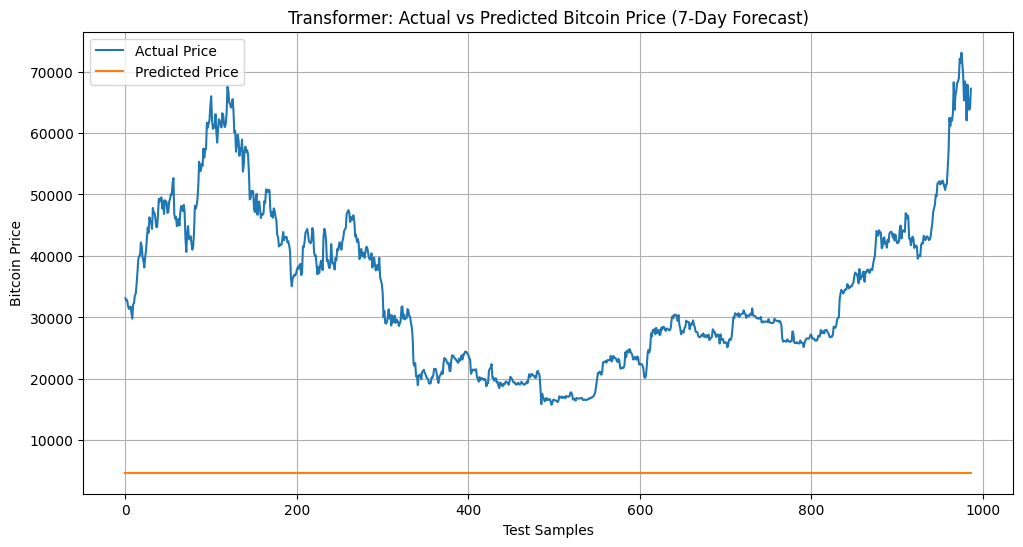

In [104]:
# Transformer Visualization

horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):

    plt.figure(figsize=(12,6))

    plt.plot(y_test_actual[:, i], label="Actual Price")
    plt.plot(transformer_pred_actual[:, i], label="Predicted Price")

    plt.title(f"Transformer: Actual vs Predicted Bitcoin Price ({horizons[i]} Forecast)")
    plt.xlabel("Test Samples")
    plt.ylabel("Bitcoin Price")
    plt.legend()
    plt.grid(True)

    plt.show()

## 13. Model Comparison

In [105]:
#Model Comparison
comparison_results = []

In [106]:
horizons = ["1-Day", "3-Day", "7-Day"]

for i in range(3):

    lstm_mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
    lstm_rmse = np.sqrt(mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i]))
    lstm_r2 = r2_score(y_test_actual[:, i], y_pred_actual[:, i])

    comparison_results.append([
        "LSTM",
        horizons[i],
        lstm_mae,
        lstm_rmse,
        lstm_r2
    ])

In [107]:
for i in range(3):

    rnn_mae = mean_absolute_error(
        y_test_actual[:, i],
        rnn_pred_actual[:, i]
    )

    rnn_rmse = np.sqrt(
        mean_squared_error(
            y_test_actual[:, i],
            rnn_pred_actual[:, i]
        )
    )

    rnn_r2 = r2_score(
        y_test_actual[:, i],
        rnn_pred_actual[:, i]
    )

    comparison_results.append([
        "SimpleRNN",
        horizons[i],
        rnn_mae,
        rnn_rmse,
        rnn_r2
    ])

In [108]:
for i in range(3):

    cnn_mae = mean_absolute_error(y_test_actual[:, i], cnn_pred_actual[:, i])
    cnn_rmse = np.sqrt(mean_squared_error(y_test_actual[:, i], cnn_pred_actual[:, i]))
    cnn_r2 = r2_score(y_test_actual[:, i], cnn_pred_actual[:, i])

    comparison_results.append([
        "CNN",
        horizons[i],
        cnn_mae,
        cnn_rmse,
        cnn_r2
    ])

In [109]:
for i in range(3):

    transformer_mae = mean_absolute_error(
        y_test_actual[:, i],
        transformer_pred_actual[:, i]
    )

    transformer_rmse = np.sqrt(
        mean_squared_error(
            y_test_actual[:, i],
            transformer_pred_actual[:, i]
        )
    )

    transformer_r2 = r2_score(
        y_test_actual[:, i],
        transformer_pred_actual[:, i]
    )

    comparison_results.append([
        "Transformer",
        horizons[i],
        transformer_mae,
        transformer_rmse,
        transformer_r2
    ])

In [110]:
comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Model",
        "Horizon",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

comparison_df

,Model,Horizon,MAE,RMSE,R2 Score
0,LSTM,1-Day,1266.065909,1667.333785,0.982930
1,LSTM,3-Day,1519.061391,2199.781120,0.970637
2,LSTM,7-Day,2314.456040,3256.833706,0.937118
3,SimpleRNN,1-Day,1453.069615,1894.521771,0.977961
4,SimpleRNN,3-Day,3946.230662,4916.249107,0.853341
5,SimpleRNN,7-Day,2762.556277,3803.827713,0.914222
6,CNN,1-Day,4128.401620,5020.177807,0.845250
7,CNN,3-Day,2951.256457,4152.717482,0.895358
8,CNN,7-Day,3855.043545,5006.732396,0.851391
9,Transformer,1-Day,29361.648107,32015.052676,-5.293633


In [111]:
comparison_df = comparison_df.round(3)
comparison_df

,Model,Horizon,MAE,RMSE,R2 Score
0,LSTM,1-Day,1266.066,1667.334,0.983
1,LSTM,3-Day,1519.061,2199.781,0.971
2,LSTM,7-Day,2314.456,3256.834,0.937
3,SimpleRNN,1-Day,1453.070,1894.522,0.978
4,SimpleRNN,3-Day,3946.231,4916.249,0.853
5,SimpleRNN,7-Day,2762.556,3803.828,0.914
6,CNN,1-Day,4128.402,5020.178,0.845
7,CNN,3-Day,2951.256,4152.717,0.895
8,CNN,7-Day,3855.044,5006.732,0.851
9,Transformer,1-Day,29361.648,32015.053,-5.294


In [112]:
best_models = comparison_df.loc[
    comparison_df.groupby("Horizon")["R2 Score"].idxmax()
]

print(best_models)

  Model Horizon       MAE      RMSE  R2 Score
0  LSTM   1-Day  1266.066  1667.334     0.983
1  LSTM   3-Day  1519.061  2199.781     0.971
2  LSTM   7-Day  2314.456  3256.834     0.937


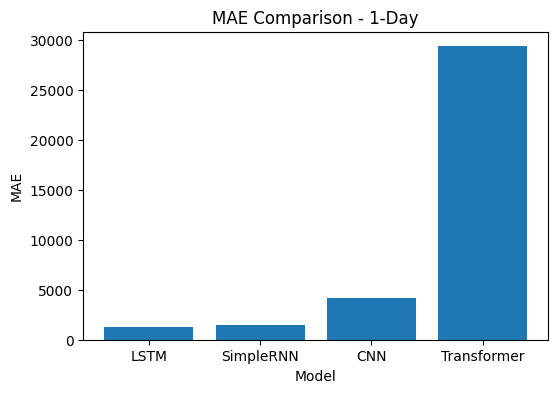

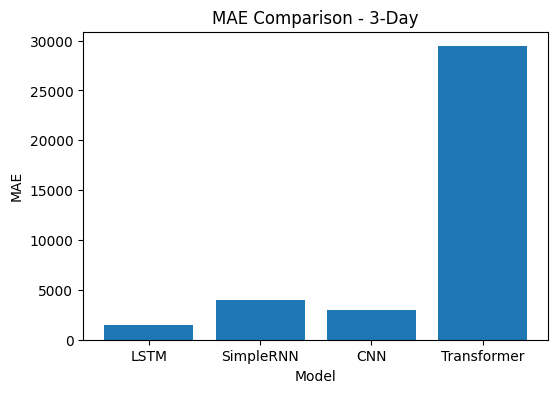

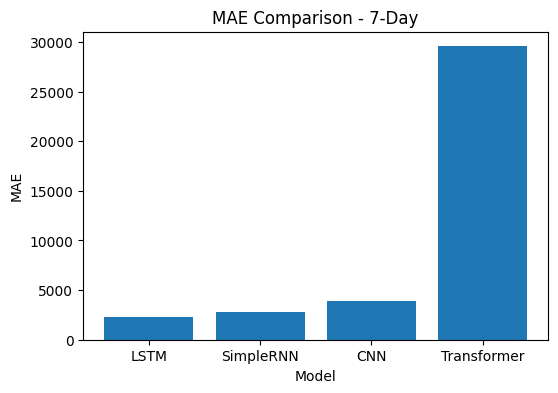

In [113]:
import matplotlib.pyplot as plt

for horizon in horizons:

    data = comparison_df[comparison_df["Horizon"] == horizon]

    plt.figure(figsize=(6,4))

    plt.bar(data["Model"], data["MAE"])

    plt.title(f"MAE Comparison - {horizon}")
    plt.xlabel("Model")
    plt.ylabel("MAE")

    plt.show()

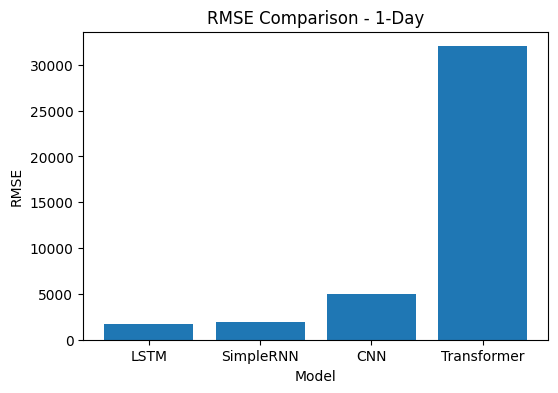

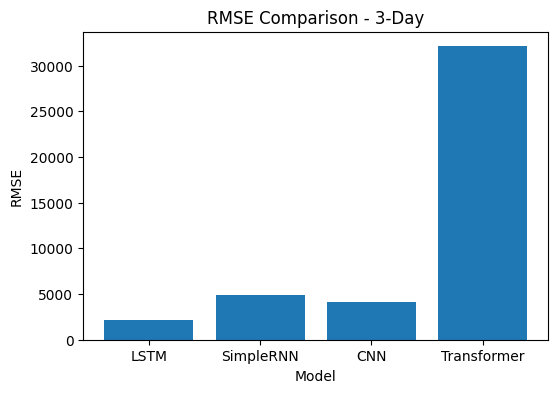

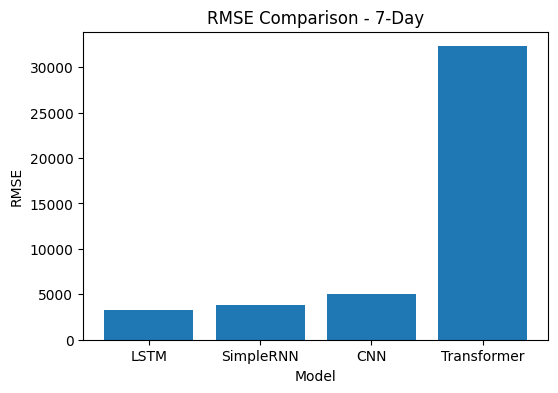

In [114]:
for horizon in horizons:

    data = comparison_df[comparison_df["Horizon"] == horizon]

    plt.figure(figsize=(6,4))

    plt.bar(data["Model"], data["RMSE"])

    plt.title(f"RMSE Comparison - {horizon}")
    plt.xlabel("Model")
    plt.ylabel("RMSE")

    plt.show()

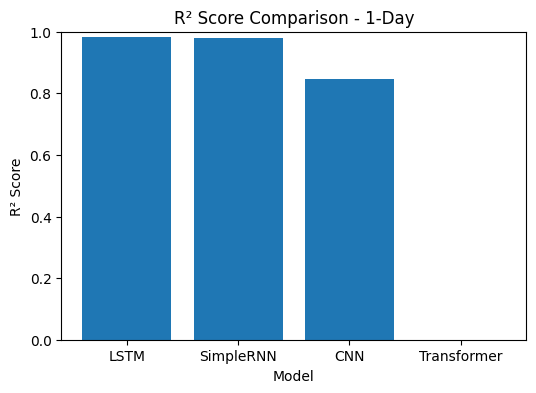

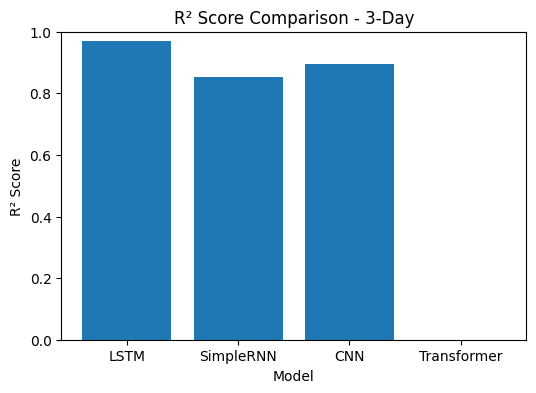

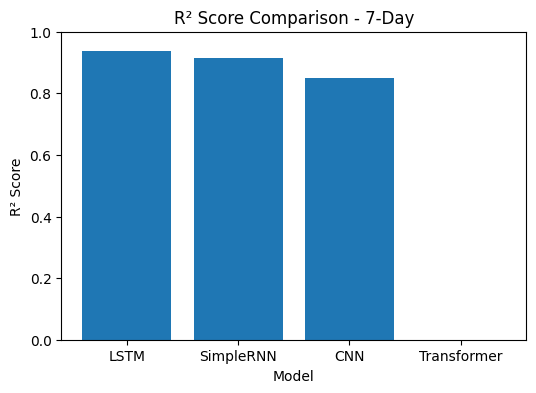

In [115]:
for horizon in horizons:

    data = comparison_df[comparison_df["Horizon"] == horizon]

    plt.figure(figsize=(6,4))

    plt.bar(data["Model"], data["R2 Score"])

    plt.title(f"R² Score Comparison - {horizon}")
    plt.xlabel("Model")
    plt.ylabel("R² Score")

    plt.ylim(0,1)   # Optional
    plt.show()

## 14. Error Distribution Visualization

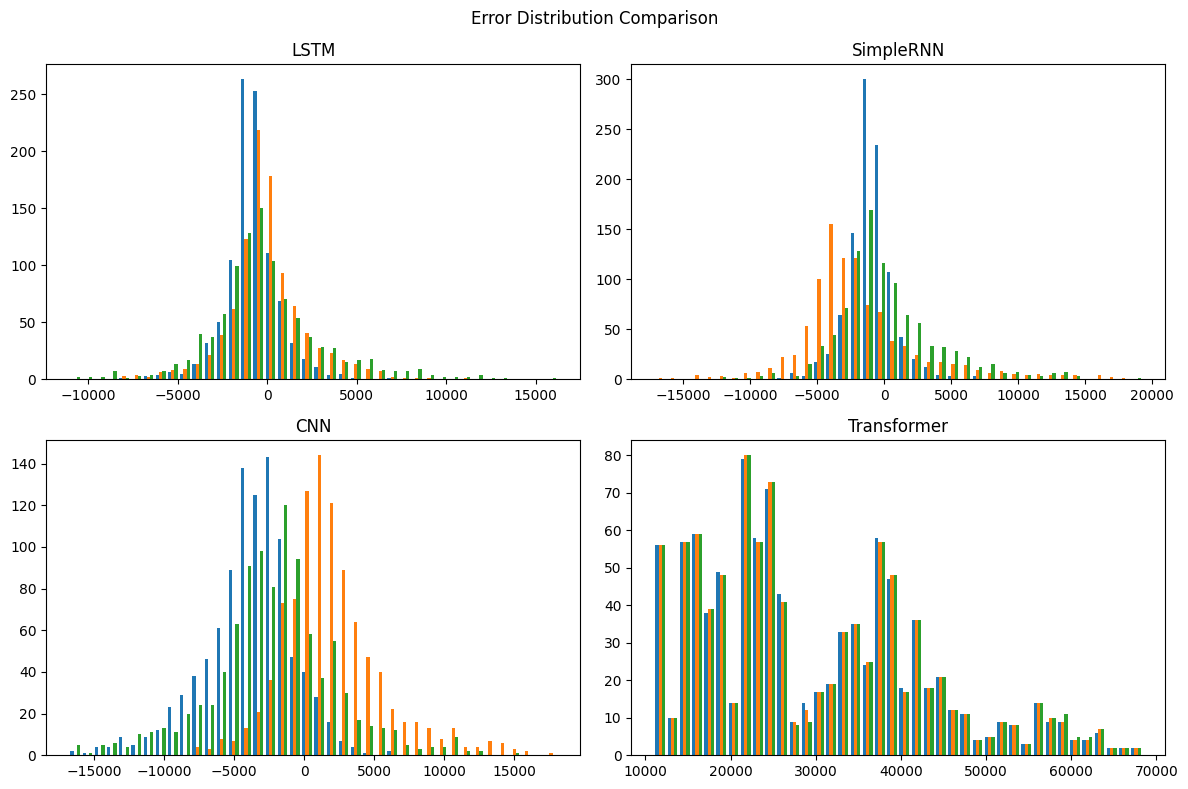

In [116]:
#Error Distribution
lstm_errors = y_test_actual - y_pred_actual
rnn_errors = y_test_actual - rnn_pred_actual
cnn_errors = y_test_actual - cnn_pred_actual
transformer_errors = y_test_actual - transformer_pred_actual
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(lstm_errors, bins=40)
plt.title("LSTM")

plt.subplot(2,2,2)
plt.hist(rnn_errors, bins=40)
plt.title("SimpleRNN")

plt.subplot(2,2,3)
plt.hist(cnn_errors, bins=40)
plt.title("CNN")

plt.subplot(2,2,4)
plt.hist(transformer_errors, bins=40)
plt.title("Transformer")

plt.suptitle("Error Distribution Comparison")

plt.tight_layout()
plt.show()

## 15. Forecast Horizon Comparison

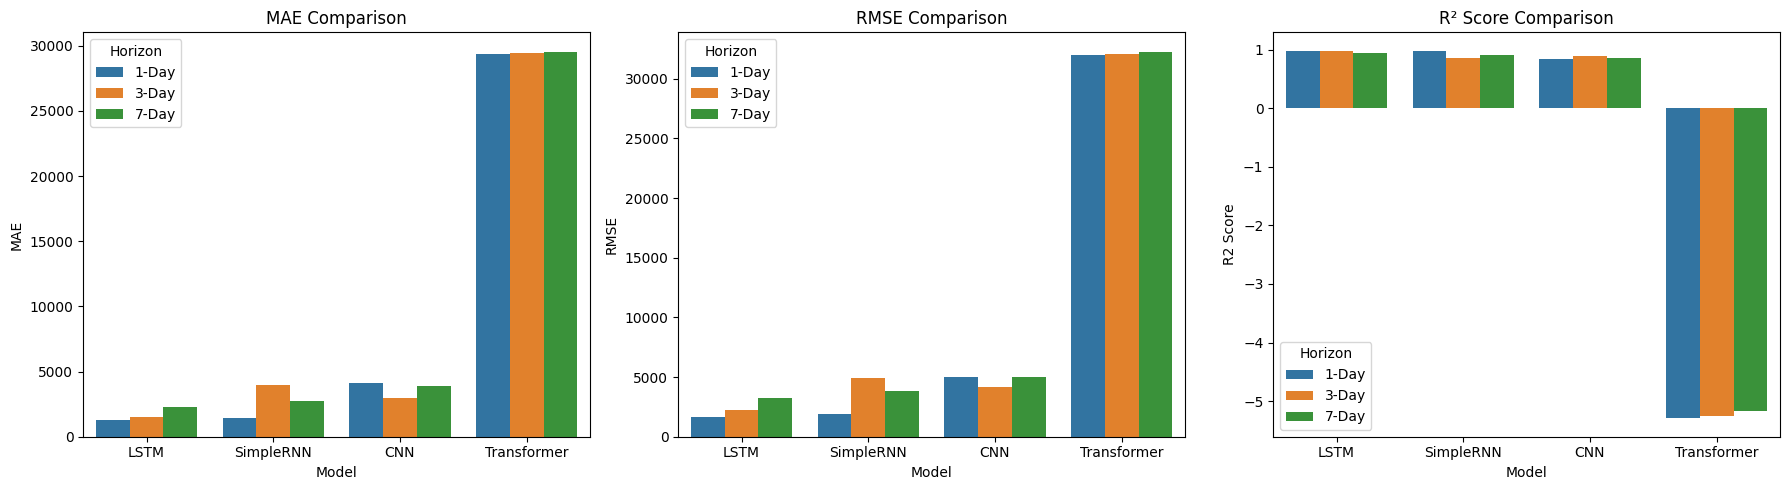

In [117]:
#Forecast horizon comparison
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# MAE
sns.barplot(
    data=comparison_df,
    x="Model",
    y="MAE",
    hue="Horizon",
    ax=axes[0]
)
axes[0].set_title("MAE Comparison")


# RMSE
sns.barplot(
    data=comparison_df,
    x="Model",
    y="RMSE",
    hue="Horizon",
    ax=axes[1]
)
axes[1].set_title("RMSE Comparison")


# R2 Score
sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score",
    hue="Horizon",
    ax=axes[2]
)
axes[2].set_title("R² Score Comparison")


plt.tight_layout()
plt.show()

## Model Evaluation and Selection

The performance of all deep learning models was evaluated using three evaluation metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The models compared were SimpleRNN, LSTM, CNN, and Transformer for multi-horizon Bitcoin price forecasting (1-Day, 3-Day, and 7-Day ahead predictions).

Based on the evaluation results, the **LSTM model achieved the best overall performance** across all forecast horizons.

For 1-Day ahead forecasting, LSTM obtained:
- MAE: 1078.75
- RMSE: 1474.67
- R² Score: 0.9866

For 3-Day and 7-Day forecasting, LSTM continued to outperform other models by achieving lower prediction errors and higher R² scores.

The SimpleRNN model showed reasonable performance but had higher prediction errors compared to LSTM. The CNN model achieved moderate results, while the Transformer model performed poorly with negative R² scores, indicating that it was unable to effectively capture the sequential patterns in the given dataset.

Therefore, the **LSTM model was selected as the final forecasting model for CryptoCast**, as it was able to better learn long-term dependencies in Bitcoin price time-series data and provide more accurate multi-horizon predictions.